# Salary Model Exploration — Summary & Insights

This notebook developed and evaluated the first generation of salary-prediction models for the project.  
The goal was not to optimise predictive accuracy, but to establish a **baseline understanding of how job-level, company-level, and skill-level features influence salary**, and to evaluate the modelling strategy that will underpin the system mechanics of the flagship project.

---

## 1. What We Tried

### **Model v01 — Category Codes (XGBoost with enable_categorical=True)**
- Encoded 6 categorical features (`state`, `sector`, `size`, `ownership`, `seniority`, `title`) using category codes.  
- Included all 27 skill indicators as binary features.  
- Used XGBoost (reg:squarederror) with simple parameters (`n_estimators=600`, `max_depth=6`, `learning_rate=0.05`).  
- Purpose: establish a clean, interpretable baseline using native categorical handling.

### **Model v02 — One-Hot Encoding**
- Re-encoded the 6 categorical variables with full one-hot encoding.  
- Kept all skill features unchanged.  
- Purpose: assess whether XGBoost benefits from expanded categorical feature space.

### **Model v03 — Refined Role Identity ("title_rich")**
- Combined `job_title_family` and `domain` into a single composite categorical variable.  
- Re-fit the model using category codes (no one-hot).  
- Purpose: test whether a more expressive representation of job identity improves prediction.

Across all models, we evaluated:
- **RMSE, MAE, R²**
- **Train/test generalisation gap**
- **Residual distributions**
- **Predicted vs actual salary scatter**
- **Feature importance ranking**

---

## 2. Key Results

### **Overall Performance**
- Test R² across all models remained stable around **0.21–0.23**.  
- Train R² ranged from **0.63–0.69**, indicating moderate learnable signal but substantial noise.  
- RMSE ≈ **33k**, MAE ≈ **26k**, consistent with real-world compensation variance.

### **Feature Importance Patterns**
- Salary variation was driven primarily by:
  - **State** (strongest categorical effect)
  - **Job identity** (`title_code` / `title_rich_code`)
  - **Sector** and **ownership**
- Skill variables contributed **small, fragmented, low-signal effects** individually.
- Model behaviour was broadly consistent across versions.

### **Residual & Prediction Structure**
- Residuals were centred correctly but wide, reflecting genuine volatility in salary data.
- Predicted vs actual salaries showed correct monotonic structure but large spread.
- No encoding method (cat-codes vs one-hot) substantially changed model behaviour.

---

## 3. What We Learned

### **1. Salary signal is real but noisy**
The model captures meaningful patterns (train R² ~0.65), but noise, estimation errors in the ads, and missing company-level information limit test performance.

### **2. Categorical information is far more predictive than individual skills**
State, sector, seniority, and job identity dominate the signal.  
Skills are individually weak predictors because their effects are **combinational**, not atomic.

### **3. One-hot vs category codes does not materially change performance**
XGBoost handled both encodings similarly; marginal differences did not justify increased dimensionality.

### **4. Combining job title + domain improves role expressiveness**
Model v03 produced cleaner feature importance patterns and slightly better alignment with job-level phenomena, confirming this encoding is conceptually preferable.

---

## 4. Conclusion & Next Steps

The exploration confirms that:
- **Our modelling framework is stable**,  
- **Our categorical encodings are reasonable**,  
- **But raw skill indicators do not meaningfully improve salary prediction** when treated independently.

The next logical step is to address **the combinational nature of skills**.  
Individually they are weak, but jointly they may represent meaningful job capability structures.

### **Next Notebook: Model v04 — Skill Dimensionality Reduction (PCA)**
We will:
- Standardize all skill features  
- Apply PCA to derive a small number of latent “skill axes”  
- Integrate these components into the XGBoost model  
- Assess whether PCA captures higher-order skill structure and improves generalisation  
- Maintain interpretability through PCA loadings and SHAP explanations  

This closes the exploratory modelling phase and establishes a clear foundation for the more systematic modelling in the next chapter.


## Set-up
* Libraries
* Path
* Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

from src.job_intel.config import CH1_PROCESSED_SALARY_MODEL_DF

In [3]:
df_ch0 = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_DF)
df_ch0.head()

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,job_title_family_data_scientist,job_title_family_scientist,title_rich,size_code,sector_code,state_code,ownership_code,seniority_code,title_code,title_rich_code
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,1,0,general_data_data_scientist,5,24,11,2,7,2,10
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,1,0,business_data_scientist,2,7,11,2,9,2,6
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,1,0,general_data_data_scientist,0,25,11,4,4,2,10
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0,0,general_data_data_analyst,3,12,10,2,5,0,8
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,1,0,general_data_data_scientist,6,5,11,2,4,2,10


# Salary model v01

#### Parameters
* n_estimators= 600
* max_depth= 6
* learning_rate=0.05
* Variables as categorical

In [4]:
response = df_ch0['sal_mean'].copy()
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_code',
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]].copy() 

In [5]:
cat_cols = [
    'size_code', 'sector_code', 'state_code', 'ownership_code', 'seniority_code', 'title_code'
]
features[cat_cols] = features[cat_cols].astype('category')

In [6]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   size_code                                 6161 non-null   category
 1   sector_code                               6161 non-null   category
 2   state_code                                6161 non-null   category
 3   ownership_code                            6161 non-null   category
 4   seniority_code                            6161 non-null   category
 5   title_code                                6161 non-null   category
 6   core_programming__basic                   6161 non-null   int64   
 7   core_programming__intermediate            6161 non-null   int64   
 8   core_programming__advanced                6161 non-null   int64   
 9   data_engineering_pipelines__basic         6161 non-null   int64   
 10  data_engineering_pipelin

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

In [8]:
from xgboost import XGBRegressor

In [26]:
n_estimators= 600
max_depth= 6
learning_rate=0.05

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=101,
    n_estimators= n_estimators,
    max_depth= max_depth,
    learning_rate=learning_rate
    )


In [27]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Prediction

In [28]:
y_pred = model.predict(X_test)

## Evaluation

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [30]:
rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)



print('=============================')
print('Model evaluation XGBRegressor')
print('=============================')
print('\n')
print(f"Parameters:\n- n_estimators = {n_estimators}\n- max_depth = {max_depth}\n- learning_rate = {learning_rate}")
print('\n')
print('Root mean squared error')
print('----------------')
print(rmse)
print('\n')
print('Mean absolute error')
print('---------------------')
print(mae)
print('\n')
print('R2 Score')
print('---------------------')
print(r2)

Model evaluation XGBRegressor


Parameters:
- n_estimators = 600
- max_depth = 6
- learning_rate = 0.05


Root mean squared error
----------------
33483.517753045126


Mean absolute error
---------------------
26020.882169378547


R2 Score
---------------------
0.21480267600297887


### Model capacity
I will test overfitting vs underfitting by comparing the R2 when prediction on the training data

In [31]:
pred_train = model.predict(X_train)
train_r2 = r2_score(y_train, pred_train)
train_r2

0.7506523867181059

There seem to be some overfitting since the Train R2 is much higher than the Test R2 (0.76 vs 0.22)

### Residual plots

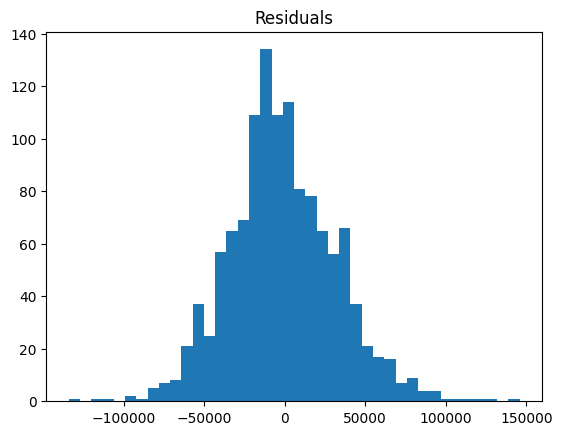

In [32]:
res = y_test - y_pred
plt.hist(res, bins=40)
plt.title('Residuals')
plt.show()

### Predicted vs Observed

Text(0.5, 1.0, 'Predicted vs Actual Salary')

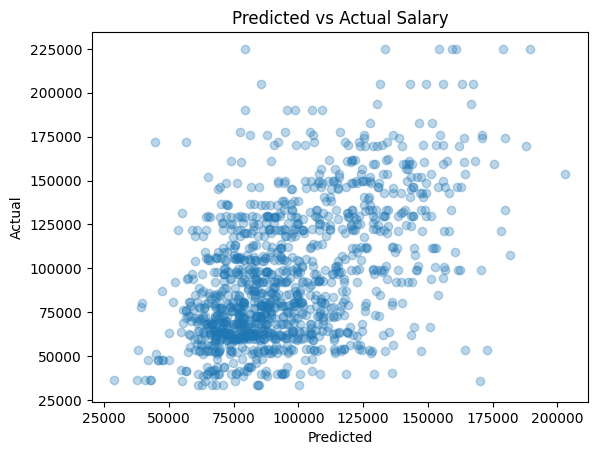

In [33]:
plt.scatter(y_pred, y_test, alpha=0.3)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actual Salary")

### Variable Importance

In [34]:
var_importance = pd.DataFrame({'features' : features.columns, 'importance' : model.feature_importances_})

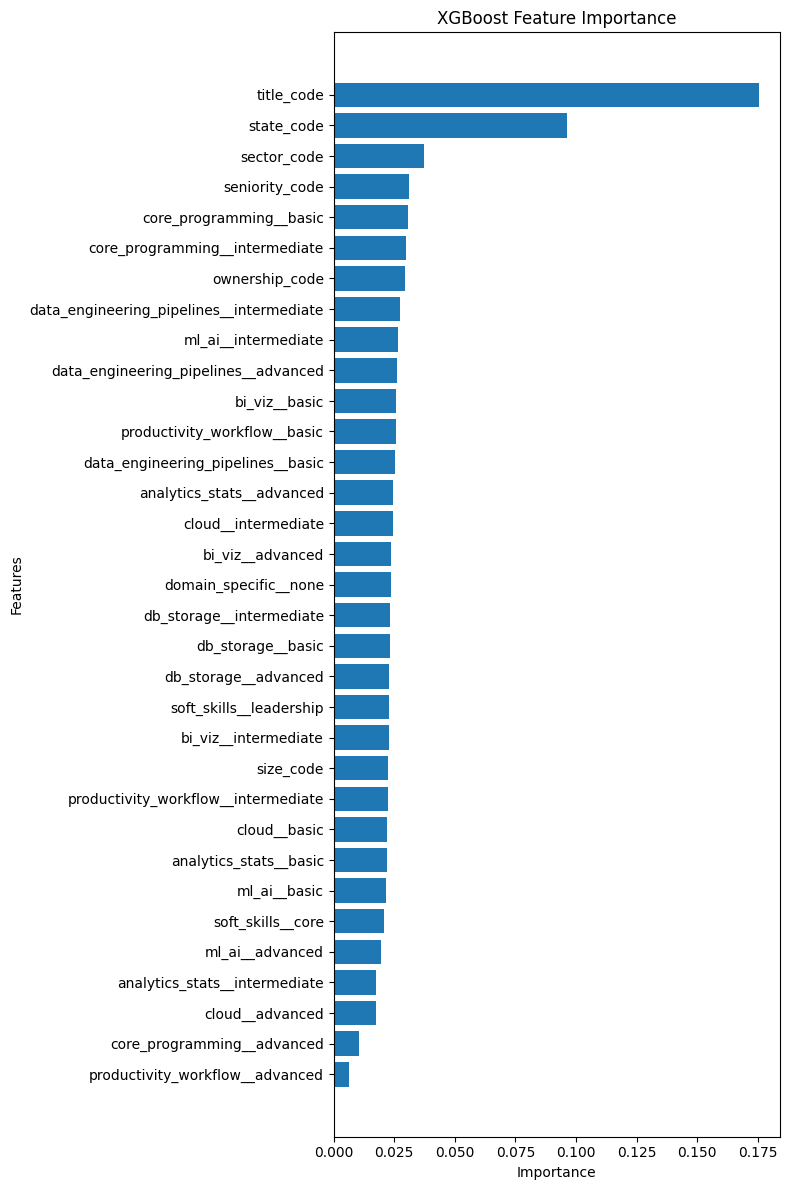

In [35]:
importance_df = var_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 12))
plt.barh(importance_df['features'], importance_df['importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.tight_layout()


### Model 1 Summary

Our first salary model used XGBoost with integer-encoded categorical variables and 27 binary skill indicators. The model achieved strong in-sample performance (train R² ≈ 0.76) but weak out-of-sample generalisation (test R² ≈ 0.22), confirming clear overfitting. Diagnostics show that the salary target behaves well (min/max/mean correlations 0.91–0.98), so the limitation is not noise in the response but insufficient feature representation. Variable importance results highlight that seniority, sector, state, job family, and title dominate the predictive signal, while individual skills contribute modestly—consistent with real-world compensation patterns. Together, these indicators show that the model captures meaningful structure but lacks robustness due to the way categorical features were encoded.

Residual & Fit Behaviour

Residual plots show large unexplained variance across the salary range, with systematic underprediction in the upper tail and heteroscedastic spread across mid-range salaries. The predicted-vs-observed scatter confirms this: predictions cluster toward the centre, failing to reproduce extremes and showing substantial vertical noise. This pattern reinforces the diagnosis that the current feature encoding does not translate into stable generalisation, even though the model can fit the training data well. These findings justify moving toward richer representations—starting with one-hot encoding—to reduce fragmentation and improve out-of-sample performance before advancing to the explainability and fairness components of the system.

# Salary model v02

#### Parameters
* n_estimators= 600
* max_depth= 6
* learning_rate=0.05
* Variables as hot-encoded

Model v02 refits the salary model using one-hot encoded versions of the six categorical variables to test whether the integer-based categorical encoding used in Model v01 was driving the train–test overfitting. By expanding each category into binary indicators, this version reduces the risk of fragmented tree splits and forces the model to learn broader, more generalisable patterns. The goal is to evaluate whether improving feature representation—without changing the algorithm or hyperparameters—can produce a tighter train–test gap and stronger out-of-sample performance. This model acts as a controlled diagnostic step before moving on to more complex feature engineering or model enhancements.

In [36]:
print(", ".join([f"'{c}'" for c in df_ch0.columns]))

'Job Description', 'Rating', 'Size', 'Founded', 'Industry', 'Sector', 'role_source', 'state', 'ownership_clean', 'job_description_clean', 'job_title_base', 'seniority_combined', 'job_title_norm', 'job_title_family', 'domain', 'sal_is_hourly', 'sal_min', 'sal_max', 'sal_mean', 'title_plus_description', 'core_programming__basic', 'core_programming__intermediate', 'core_programming__advanced', 'data_engineering_pipelines__basic', 'data_engineering_pipelines__intermediate', 'data_engineering_pipelines__advanced', 'ml_ai__basic', 'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic', 'analytics_stats__intermediate', 'analytics_stats__advanced', 'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced', 'cloud__basic', 'cloud__intermediate', 'cloud__advanced', 'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced', 'productivity_workflow__basic', 'productivity_workflow__intermediate', 'productivity_workflow__advanced', 'soft_skills__core', 'soft_skills__leader

In [37]:
response = df_ch0['sal_mean'].copy()
features = df_ch0[[
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none',
            'Size_1 to 50 employees', 'Size_10000+ employees', 'Size_1001 to 5000 employees', 
            'Size_201 to 500 employees', 'Size_5001 to 10000 employees', 'Size_501 to 1000 employees', 
            'Size_51 to 200 employees', 'Size_Unknown', 'Sector_Accounting & Legal', 'Sector_Aerospace & Defense', 
            'Sector_Agriculture & Forestry', 'Sector_Arts, Entertainment & Recreation', 'Sector_Biotech & Pharmaceuticals', 
            'Sector_Business Services', 'Sector_Construction, Repair & Maintenance', 'Sector_Consumer Services', 
            'Sector_Education', 'Sector_Finance', 'Sector_Government', 'Sector_Health Care', 'Sector_Information Technology', 
            'Sector_Insurance', 'Sector_Manufacturing', 'Sector_Media', 'Sector_Mining & Metals', 'Sector_Non-Profit', 
            'Sector_Oil, Gas, Energy & Utilities', 'Sector_Real Estate', 'Sector_Restaurants, Bars & Food Services', 'Sector_Retail', 
            'Sector_Telecommunications', 'Sector_Transportation & Logistics', 'Sector_Travel & Tourism', 'Sector_Unknown', 'state_AZ', 
            'state_CA', 'state_CO', 'state_DE', 'state_FL', 'state_GA', 'state_IL', 'state_IN', 'state_KS', 'state_NC', 'state_NJ', 
            'state_NY', 'state_OH', 'state_PA', 'state_SC', 'state_TX', 'state_UT', 'state_VA', 'state_WA', 'state_international', 
            'ownership_clean_government', 'ownership_clean_nonprofit', 'ownership_clean_private', 'ownership_clean_public', 'ownership_clean_unknown', 
            'seniority_combined_assistant', 'seniority_combined_executive', 'seniority_combined_junior', 'seniority_combined_lead', 
            'seniority_combined_manager', 'seniority_combined_mid', 'seniority_combined_principal', 'seniority_combined_senior', 'seniority_combined_supervisor', 
            'seniority_combined_unknown', 'job_title_family_data_analyst', 'job_title_family_data_engineer', 'job_title_family_data_scientist', 'job_title_family_scientist'
            ]].copy() 

In [38]:
len(features.columns)

100

In [39]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6161 entries, 0 to 6160
Data columns (total 100 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   core_programming__basic                    6161 non-null   int64
 1   core_programming__intermediate             6161 non-null   int64
 2   core_programming__advanced                 6161 non-null   int64
 3   data_engineering_pipelines__basic          6161 non-null   int64
 4   data_engineering_pipelines__intermediate   6161 non-null   int64
 5   data_engineering_pipelines__advanced       6161 non-null   int64
 6   ml_ai__basic                               6161 non-null   int64
 7   ml_ai__intermediate                        6161 non-null   int64
 8   ml_ai__advanced                            6161 non-null   int64
 9   analytics_stats__basic                     6161 non-null   int64
 10  analytics_stats__intermediate              6161

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

In [41]:
from xgboost import XGBRegressor
n_estimators= 600
max_depth= 6
learning_rate=0.05

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=101,
    n_estimators= n_estimators,
    max_depth= max_depth,
    learning_rate=learning_rate
    )


In [42]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
pred_train = model.predict(X_train)
train_r2 = r2_score(y_train, pred_train)


print('=============================')
print('Model evaluation XGBRegressor')
print('=============================')
print('\n')
print(f"Parameters:\n- n_estimators = {n_estimators}\n- max_depth = {max_depth}\n- learning_rate = {learning_rate}")
print('\n')
print('Root mean squared error')
print('----------------')
print(rmse)
print('\n')
print('Mean absolute error')
print('---------------------')
print(mae)
print('\n')
print('R2 Score')
print('---------------------')
print(r2)
print('\n')
print('R2 Score (train)')
print('---------------------')
print(train_r2)

Model evaluation XGBRegressor


Parameters:
- n_estimators = 600
- max_depth = 6
- learning_rate = 0.05


Root mean squared error
----------------
33483.517753045126


Mean absolute error
---------------------
26020.882169378547


R2 Score
---------------------
0.21480267600297887


R2 Score (train)
---------------------
0.6240916490493904


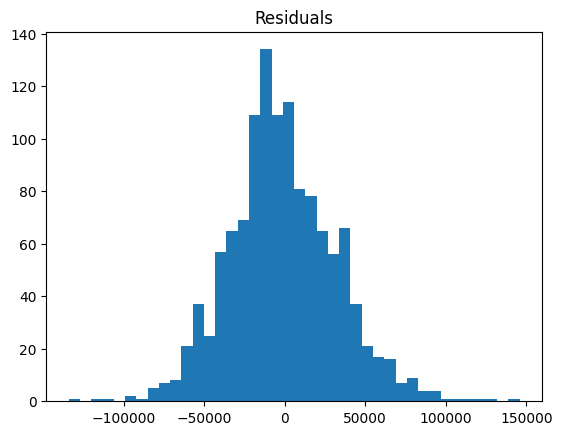

In [44]:
res = y_test - y_pred
plt.hist(res, bins=40)
plt.title('Residuals')
plt.show()

Text(0.5, 1.0, 'Predicted vs Actual Salary')

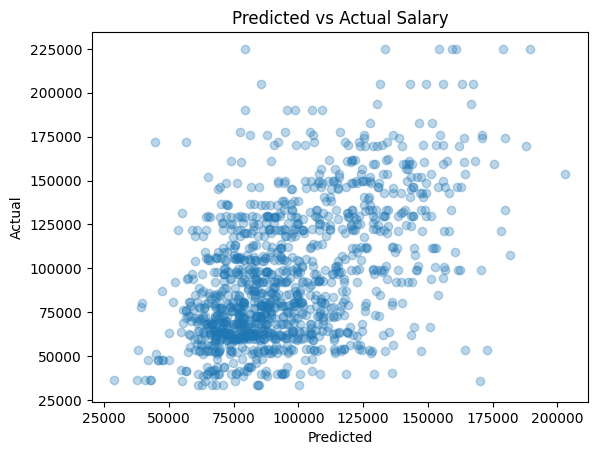

In [45]:
plt.scatter(y_pred, y_test, alpha=0.3)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actual Salary")

In [46]:
var_importance = pd.DataFrame({'features' : features.columns, 'importance' : model.feature_importances_})

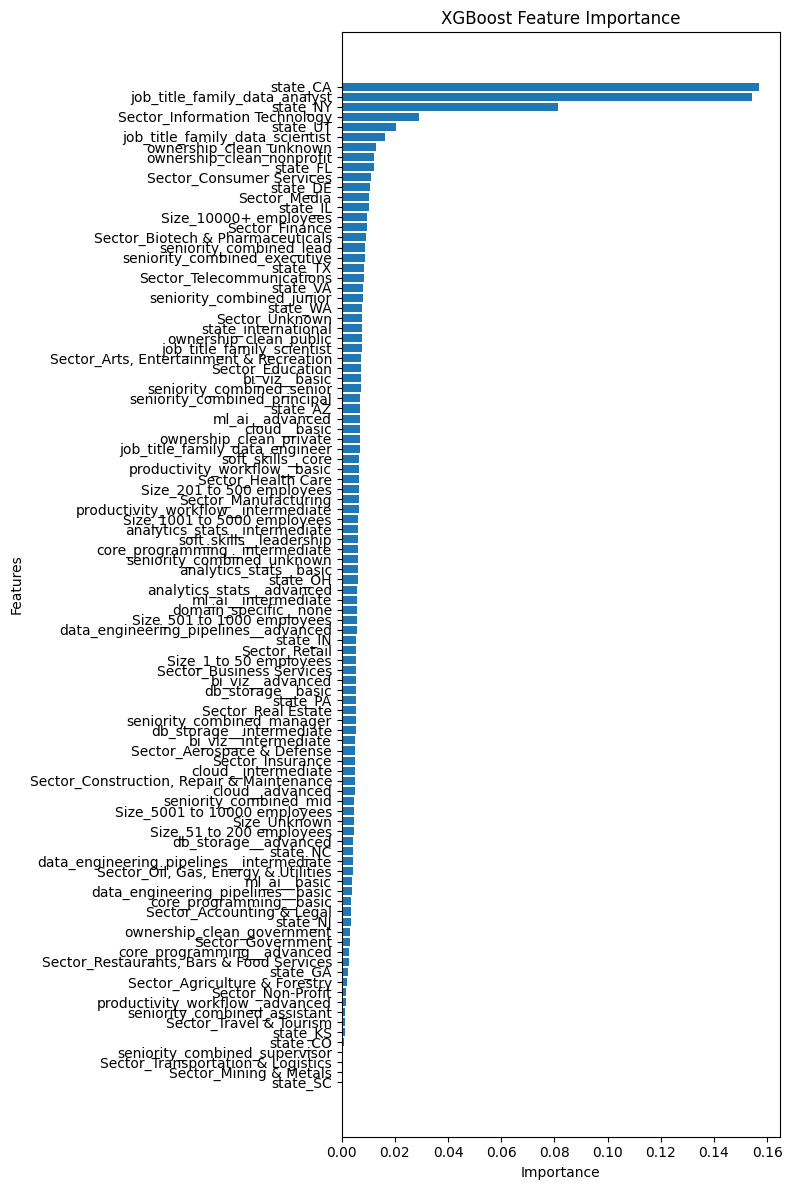

In [47]:
importance_df = var_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 12))
plt.barh(importance_df['features'], importance_df['importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.tight_layout()

## Model v02 summary

After one-hot encoding, the model shows reduced overfitting but no improvement in test performance. Importance is distributed across many category dummies, with salary variation still driven primarily by job family and state. Skill features continue to contribute only marginally, indicating that the current feature set does not contain enough information to generalise salary predictions beyond broad title- and location-level differences. The unchanged R² confirms that performance is limited by feature depth, not model choice or encoding strategy.

# SALARY Model V03 

### Richer title variable that includes domain

#### Parameters

* n_estimators= 600
* max_depth= 6
* learning_rate=0.05
* Variables as categorical


Model v03 introduces a refined representation of job structure by combining job_title_family and domain into a single categorical feature, job_index. The motivation for this change is that salary is driven primarily by role identity and functional context, and the original variables were too coarse when treated independently. By merging them, we create a more informative and stable signal that better captures real job distinctions without exploding feature dimensionality. Model v03 retains the same structure and parameters as Model v01, allowing a clean, controlled test of whether this enhanced job-level encoding improves generalisation.

In [48]:
response = df_ch0['sal_mean'].copy()
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code',
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]].copy() 

In [49]:
cat_cols = [
    'size_code', 'sector_code', 'state_code', 'ownership_code', 'seniority_code', 'title_rich_code'
]
features[cat_cols] = features[cat_cols].astype('category')

In [50]:
X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

In [51]:
n_estimators= 600
max_depth= 6
learning_rate=0.05

model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    enable_categorical=True,
    random_state=101,
    n_estimators= n_estimators,
    max_depth= max_depth,
    learning_rate=learning_rate
    )


In [52]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [53]:
rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
pred_train = model.predict(X_train)
train_r2 = r2_score(y_train, pred_train)


print('=============================')
print('Model evaluation XGBRegressor')
print('=============================')
print('\n')
print(f"Parameters:\n- n_estimators = {n_estimators}\n- max_depth = {max_depth}\n- learning_rate = {learning_rate}")
print('\n')
print('Root mean squared error')
print('----------------')
print(rmse)
print('\n')
print('Mean absolute error')
print('---------------------')
print(mae)
print('\n')
print('R2 Score')
print('---------------------')
print(r2)
print('\n')
print('R2 Score (train)')
print('---------------------')
print(train_r2)

Model evaluation XGBRegressor


Parameters:
- n_estimators = 600
- max_depth = 6
- learning_rate = 0.05


Root mean squared error
----------------
33483.517753045126


Mean absolute error
---------------------
26020.882169378547


R2 Score
---------------------
0.21480267600297887


R2 Score (train)
---------------------
0.7723238344577705


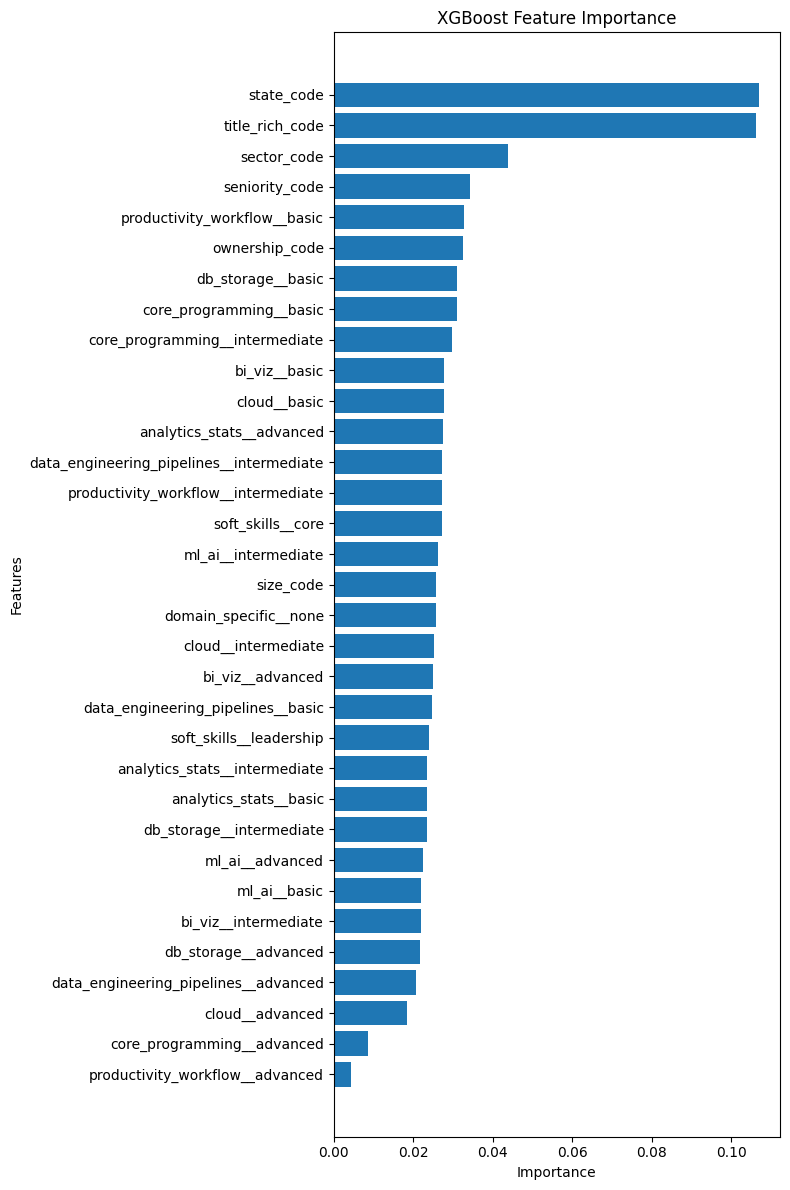

In [54]:
var_importance = pd.DataFrame({'features' : features.columns, 'importance' : model.feature_importances_})
importance_df = var_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 12))
plt.barh(importance_df['features'], importance_df['importance'])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.tight_layout()

Model v03 replaced the original two job-identity variables (job_title_family and domain) with a richer combined feature (title_rich_code) to better differentiate role types. The expectation was that this would sharpen the salary signal by providing finer job segmentation without the dimensional explosion of one-hot encoding.
However, the results are unchanged. This means the model’s predictive ceiling did not move even after improving job representation.

Your feature-importance plot confirms why:

- Only state and job identity (the new title_rich_code) carry real signal.
- Skills contribute only tiny, noisy increments.
- Company-level variation cannot be captured because the dataset is too small and too heterogeneous (2,000+ companies, 6k rows).
- The remaining variables are weakly correlated with salary and highly overlapping across jobs.

In other words, you improved the job feature, but the dataset itself does not contain any strong additional predictors, so the baseline model performance does not change.

# === END of Notebook ===